In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision.transforms import v2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# defining transform
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(root = "./data", train = True, download = True, transform = transform )
test_dataset = torchvision.datasets.CIFAR10(root = "./data", train = False, download = True, transform = transform)

train_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True, pin_memory = torch.cuda.is_available())
test_loader = DataLoader(test_dataset, shuffle = False , batch_size = 128, pin_memory = torch.cuda.is_available())

classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [12]:
from torch.nn.modules.linear import Linear
from torch.nn.modules.flatten import Flatten
class Convolution(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Conv2d(3,32,3,1,1),
        nn.ReLU(),

        nn.Conv2d(32,64,3,1,1),
        nn.ReLU(),

        nn.MaxPool2d(2,2),

        nn.Conv2d(64,128,3,1,1),
        nn.ReLU(),

        nn.Conv2d(128,128,3,1,1),
        nn.ReLU(),

        nn.MaxPool2d(2,2),

        nn.Flatten(),

        nn.Linear(128*8*8, 512),
        nn.ReLU(),

        nn.Linear(512,10)
    )

  def forward(self,X):
    return self.model(X)


model = Convolution()
model = model.to(device)

print(model)



Convolution(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=8192, out_features=512, bias=True)
    (12): ReLU()
    (13): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
lr = 0.001
epochs = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = lr)

Epoch : [1 / 5] : 3.2939426631
Epoch : [2 / 5] : 2.3034033861
Epoch : [3 / 5] : 2.3034093221
Epoch : [4 / 5] : 2.3032593569
Epoch : [5 / 5] : 2.3034105837


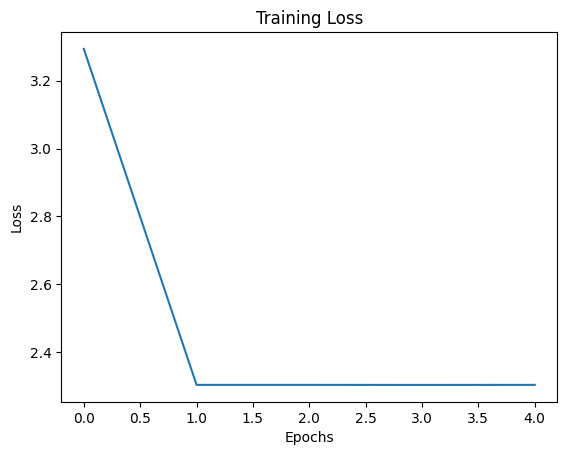

In [14]:
train_losses = []
for epoch in range(epochs):
  model.train()
  total_epoch_loss = 0;
  for batch_X, batch_y in train_loader:
    batch_X = batch_X.to(device)
    batch_y = batch_y.to(device)

    y_pred = model(batch_X)
    loss = loss_fn(y_pred, batch_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss +=loss.item()
  average_epoch_loss = total_epoch_loss/len(train_loader)
  train_losses.append(average_epoch_loss)
  print(f"Epoch : [{epoch + 1 } / {epochs}] : {average_epoch_loss:.10f}")
plt.plot([t1 for t1 in train_losses])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


In [15]:
correct = 0
total_labels = len(test_dataset)
model.eval()

with torch.no_grad():
  for batch_X, batch_y in test_loader:
    batch_correct_preds = 0
    batch_X = batch_X.to(device)
    batch_y  = batch_y.to(device)
    y_pred = model(batch_X)
    predicted_labels = torch.argmax(y_pred, dim =1)
    batch_correct_preds += (predicted_labels == batch_y).sum().item()
    correct += batch_correct_preds

print(correct)
acc = correct/ total_labels
print(f"The accuracy of the currrent model is : {acc*100:.10f}")


1000
The accuracy of the currrent model is : 10.0000000000
